In [1]:
from processing.auto_cluster_dl import auto_cluster_dl_hdbscan
from processing.clahe import chalhe_images
from processing.make_crops import make_crops
from processing.megadetector_step import megadetector_classify
from processing.divide import divide_images
from processing.remove_footer import remove_footer
import os
import shutil
import numpy as np

# --- CONFIGURACIÓN ---
PATH = 'Ecuador'
SRC_IMAGES = os.path.join(PATH, 'dataset_ecuador')
IMAGES = os.path.join(PATH, 'images')
# Carpetas intermedias
SORTED_DIR = os.path.join(PATH, 'images_sorted')
CROPS_RAW_DIR = os.path.join(PATH, 'crops')
CROPS_CLAHE_DIR = os.path.join(PATH, 'crops_clahe_processed')
CLUSTERS_OUTPUT = os.path.join(PATH, 'Clusters')       # Salida final
# Definimos rutas claras

ANIMALS_FOLDER = 'Animales'
EMPTY_FOLDER = 'Vacias'

path_animales_img = os.path.join(SORTED_DIR, ANIMALS_FOLDER)

/home/ariel/Desktop/iwildcam_preprocessing_pipeline/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Pipeline

In [2]:
# --- PIPELINE ---

print("=== INICIANDO PIPELINE (MegaDetector -> Crop -> CLAHE -> ResNet50) ===")

=== INICIANDO PIPELINE (MegaDetector -> Crop -> CLAHE -> ResNet50) ===


# Box Generations

In [3]:
# 1. MEGADETECTOR
print("\n--- Paso 1: MegaDetector ---")
if os.path.exists('resultados_megadetector.json'):
    print("JSON detectado. Saltando.")
else:
    megadetector_classify(
        input_folder=SRC_IMAGES,
        output_file='resultados_megadetector.json',
        model_version='MDV5A',
        conf_threshold=0.2,
        recursive=True
    )


--- Paso 1: MegaDetector ---
--- Iniciando MegaDetector Pipeline ---
Carpeta de imágenes: /home/ariel/Desktop/iwildcam_preprocessing_pipeline/Ecuador/dataset_ecuador
Buscando imágenes...
Se encontraron 5900 imágenes.
Redimensionando imágenes a máximo 1600 px en: /home/ariel/Desktop/iwildcam_preprocessing_pipeline/Ecuador/dataset_ecuador/_resized_for_md
Iniciando resize paralelo con 4 núcleos...


Redimensionando (Multiprocess): 100%|██████████| 5900/5900 [00:32<00:00, 179.57it/s]


Cargando modelo y ejecutando detección...
Model v5a.0.1 already exists and is valid at /tmp/megadetector_models/md_v5a.0.1.pt
PyTorch reports 2 available CUDA devices
GPU available: True
PyTorch reports 2 available CUDA devices
GPU available: True
Loading PT detector with compatibility mode classic
Loaded image size 1280 from model metadata
Using model stride: 64
PTDetector using device cuda:0


Fusing layers... 
Fusing layers... 
Model summary: 733 layers, 140054656 parameters, 0 gradients, 208.8 GFLOPs
Model summary: 733 layers, 140054656 parameters, 0 gradients, 208.8 GFLOPs


Loaded model in 0.87 seconds


100%|██████████| 185/185 [03:07<00:00,  1.01s/it]

Guardando resultados en /home/ariel/Desktop/iwildcam_preprocessing_pipeline/resultados_megadetector.json...
Output file saved at /home/ariel/Desktop/iwildcam_preprocessing_pipeline/resultados_megadetector.json
--- ¡Proceso Terminado! ---


In [2]:
# 2. DIVIDE
print("\n--- Paso 2: Dividir ---")
divide_images(
    json_file='resultados_megadetector.json',
    source_folder=SRC_IMAGES,
    dest_root=SORTED_DIR,
    animals_folder_name=ANIMALS_FOLDER,
    empty_folder_name=EMPTY_FOLDER,
    conf_threshold=0.4,
    accepted_categories=['1']
)


--- Paso 2: Dividir ---
Cargando resultados_megadetector.json...
--- Comenzando la clasificación ---
Movido: _resized_for_md/ecuador1_cam1612_20150101_010031_img_1113.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150101_010409_img_1114.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150101_013820_img_1217.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150101_225927_img_1220.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150103_025339_img_1231.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150103_054019_img_1232.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150103_062943_img_1233.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150104_010724_img_1239.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150104_011418_img_1240.jpg → Vacias (Conf: 0.00)
Movido: _resized_for_md/ecuador1_cam1612_20150104_013417_img_1241.jpg 

# Crops Generations

In [3]:
# 3. MAKE CROPS
print("\n--- Paso 3: Recortes (Crops) ---")

make_crops(
    json_file='resultados_megadetector.json',
    input_folder=path_animales_img,
    output_folder=CROPS_RAW_DIR,
    conf_threshold=0.4,
    accepted_categories=['1']
)

shutil.rmtree(SORTED_DIR)


--- Paso 3: Recortes (Crops) ---
Cargando resultados_megadetector.json...
--- Fase 1: Analizando dimensiones para encontrar la mediana ---


Analizando tamaños: 100%|██████████| 5900/5900 [00:00<00:00, 83364.70it/s]



>>> TAMAÑO MEDIO CALCULADO: 714x523 px

--- Fase 2: Iniciando Recorte Inteligente ---


Generando crops: 100%|██████████| 5900/5900 [00:09<00:00, 626.22it/s]  



--- Resumen Final ---
Mediana usada: 714x523 px
Recortes generados: 1830
Errores: 0


# Filter and preprocessing image section

In [4]:
# 4. CLAHE
print("\n--- Paso 4: CLAHE ---")

chalhe_images(
    input_dir=CROPS_RAW_DIR,
    output_dir=CROPS_CLAHE_DIR
)

shutil.rmtree(CROPS_RAW_DIR)


--- Paso 4: CLAHE ---
Procesando 1830 imágenes con CLAHE + Normalize + Pad + Resize...


  1%|          | 11/1830 [00:00<00:16, 107.76it/s]

pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing

  4%|▍         | 80/1830 [00:00<00:06, 287.69it/s]

bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World

...

pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing

 97%|█████████▋| 1768/1830 [00:05<00:00, 344.97it/s]

pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing

100%|██████████| 1830/1830 [00:05<00:00, 338.99it/s]


pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing (leve)
pad → cuadrada
resize → tamaño uniforme para ViT
normalizar color (Gray World)
CLAHE
bilateral smoothing

# Image reduction and features extraction

In [2]:
# 5. AUTO CLUSTER (RESNET)
print("\n--- Paso 5: Clustering con ViT + UMAP ---")
# CAMBIO: Usamos la función que integra ResNet
clusterer, embedding = auto_cluster_dl_hdbscan(
    input_dir=CROPS_CLAHE_DIR,    # Usamos los crops mejorados
    output_dir=CLUSTERS_OUTPUT,
    min_cluster_size=15
)

print(f"\n¡LISTO! Revisa la carpeta: {CLUSTERS_OUTPUT}")


--- Paso 5: Clustering con ViT + UMAP ---
--- Paso 1: Extracción de Features con ViT ---
Features ya extraídos previamente. Cargando...
Features cargados: (1830, 1024)
--- Paso 2: Reducción de Dimensionalidad (UMAP) ---


/home/ariel/Desktop/iwildcam_preprocessing_pipeline/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ariel/Desktop/iwildcam_preprocessing_pipeline/.venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


Dimensiones reducidas con UMAP: (1830, 15)
--- Paso 3: Clustering con HDBSCAN (min_cluster_size=15) ---

>>> RESULTADO: Se encontraron 33 clusters y 647 imágenes de Ruido (-1).
--- Paso 4: Organizando archivos ---


Moviendo archivos: 100%|██████████| 1830/1830 [00:00<00:00, 12474.81it/s]


--- RESUMEN FINAL ---
Cluster_00: 27 imágenes
Cluster_01: 29 imágenes
Cluster_02: 43 imágenes
Cluster_03: 23 imágenes
Cluster_04: 22 imágenes
Cluster_05: 26 imágenes
Cluster_06: 22 imágenes
Cluster_07: 18 imágenes
Cluster_08: 18 imágenes
Cluster_09: 38 imágenes
Cluster_10: 54 imágenes
Cluster_11: 16 imágenes
Cluster_12: 34 imágenes
Cluster_13: 16 imágenes
Cluster_14: 22 imágenes
Cluster_15: 27 imágenes
Cluster_16: 85 imágenes
Cluster_17: 20 imágenes
Cluster_18: 34 imágenes
Cluster_19: 106 imágenes
Cluster_20: 76 imágenes
Cluster_21: 28 imágenes
Cluster_22: 62 imágenes
Cluster_23: 23 imágenes
Cluster_24: 56 imágenes
Cluster_25: 21 imágenes
Cluster_26: 33 imágenes
Cluster_27: 63 imágenes
Cluster_28: 19 imágenes
Cluster_29: 19 imágenes
Cluster_30: 42 imágenes
Cluster_31: 26 imágenes
Cluster_32: 35 imágenes
Cluster_Ruido_Outliers: 647 imágenes

¡LISTO! Revisa la carpeta: Ecuador/Clusters


# Metrics Report

# Unsupervised metrics

*   **Silhouette Score:** Measures how well each point is assigned to its correct cluster (good separation).
*   **Cohesion (Heuristic Cohesion):** Measures how tightly packed the points within a cluster are.
*   **Confidence (HDBSCAN):** Evaluates how confident HDBSCAN is that a point belongs to a cluster.
*   **Persistence (HDBSCAN):** Measures how stable a cluster is over time.

In [3]:
from sklearn.metrics import silhouette_score

labels = clusterer.fit_predict(embedding)

# --- 3.1 MÉTRICA: SILHOUETTE (ignorando ruido) ---
mask = labels != -1

if np.sum(mask) > 1 and len(set(labels[mask])) > 1:
    silhouette = silhouette_score(
        embedding[mask],
        labels[mask],
        metric='euclidean'  # coherente con HDBSCAN en UMAP
    )
    print(f"Silhouette Score (sin ruido): {silhouette:.4f}")
else:
    print("No se puede calcular Silhouette (muy pocos clusters o puntos).")

Silhouette Score (sin ruido): 0.6546


In [4]:
from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(embedding, labels)

cluster_silhouette = {}
for c in set(labels):
    if c == -1: continue
    cluster_silhouette[c] = (sil_samples[labels == c].mean())

In [5]:
from scipy.spatial.distance import pdist

def cohesion(cluster_points):
    return pdist(cluster_points).mean()

cluster_cohesion = {}

for c in set(labels):
    if c == -1: continue
    points = embedding[labels == c]
    cluster_cohesion[c] = cohesion(points)

In [6]:
import numpy as np

vals = np.array(list(cluster_cohesion.values()))
norm = (vals - vals.min()) / (vals.max() - vals.min())

print(dict(zip(cluster_cohesion.keys(), norm)))

{np.int64(0): np.float64(0.09070345001420098), np.int64(1): np.float64(0.09099103377697067), np.int64(2): np.float64(0.18357825319902063), np.int64(3): np.float64(0.0), np.int64(4): np.float64(0.2788059278266755), np.int64(5): np.float64(0.08897651115325873), np.int64(6): np.float64(0.39764140036883877), np.int64(7): np.float64(0.42361301650180855), np.int64(8): np.float64(0.0010558755262102672), np.int64(9): np.float64(0.22319829509088465), np.int64(10): np.float64(0.40593260297473105), np.int64(11): np.float64(0.1057698839965516), np.int64(12): np.float64(0.33371129108349146), np.int64(13): np.float64(0.10276711183939108), np.int64(14): np.float64(0.11740399545802171), np.int64(15): np.float64(0.5179205140809835), np.int64(16): np.float64(1.0), np.int64(17): np.float64(0.26556648880845224), np.int64(18): np.float64(0.41748246448886467), np.int64(19): np.float64(0.9660804365148252), np.int64(20): np.float64(0.6165770153842121), np.int64(21): np.float64(0.5230652160304533), np.int64(22

In [7]:
cluster_confidence = {}

for c in set(labels):
    if c == -1: continue
    cluster_confidence[c] = clusterer.probabilities_[labels == c].mean()

In [8]:
clusterer.cluster_persistence_

array([0.64911894, 0.64999394, 0.73760843, 0.68047963, 0.28039947,
       0.35284593, 0.12895493, 0.07023573, 0.03069866, 0.277366  ,
       0.11961437, 0.00916663, 0.08674107, 0.00650995, 0.03450527,
       0.04072291, 0.16289497, 0.07014385, 0.10057622, 0.06822602,
       0.11118108, 0.03713045, 0.2332506 , 0.06742426, 0.22852201,
       0.03472624, 0.05599092, 0.10130281, 0.01007539, 0.00752212,
       0.13571326, 0.12476934, 0.04689678])

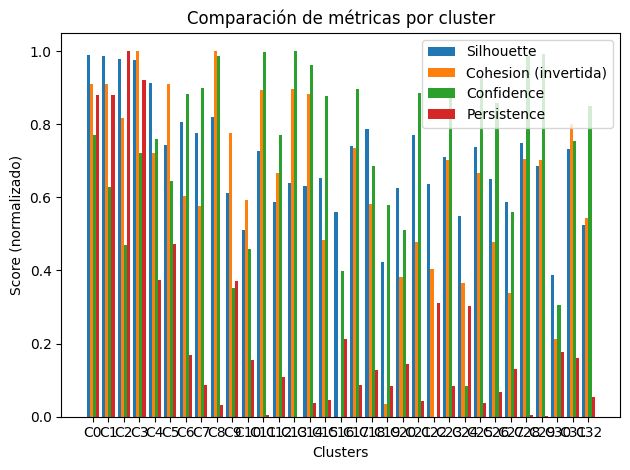

In [9]:
import numpy as np
import matplotlib.pyplot as plt

clusters = sorted(cluster_silhouette.keys())

# --- 1. Extraer métricas en orden consistente ---
sil_vals = np.array([cluster_silhouette[c] for c in clusters])
coh_vals = np.array([cluster_cohesion[c] for c in clusters])
conf_vals = np.array([cluster_confidence[c] for c in clusters])

# --- 2. Normalizar cohesión (ya la tienes, pero lo hacemos ordenado) ---
coh_norm = (coh_vals - coh_vals.min()) / (coh_vals.max() - coh_vals.min())

# Invertir cohesión para que "más alto = mejor"
coh_norm_inv = 1 - coh_norm

# --- 3. Normalizar confidence (opcional, ya suele estar en [0,1]) ---
conf_norm = (conf_vals - conf_vals.min()) / (conf_vals.max() - conf_vals.min())

# --- 4. Persistencia (ojo: HDBSCAN ya la da por cluster en orden interno) ---
# Asegúrate que el orden coincide con tus labels
persistence_vals = clusterer.cluster_persistence_
persistence_norm = (persistence_vals - persistence_vals.min()) / (
    persistence_vals.max() - persistence_vals.min()
)

# --- 5. Preparar gráfica ---
x = np.arange(len(clusters))
width = 0.2

plt.figure()

plt.bar(x - 1.5*width, sil_vals, width, label='Silhouette')
plt.bar(x - 0.5*width, coh_norm_inv, width, label='Cohesion (invertida)')
plt.bar(x + 0.5*width, conf_norm, width, label='Confidence')
plt.bar(x + 1.5*width, persistence_norm[:len(clusters)], width, label='Persistence')

# --- 6. Labels ---
plt.xticks(x, [f"C{c}" for c in clusters])
plt.xlabel("Clusters")
plt.ylabel("Score (normalizado)")
plt.title("Comparación de métricas por cluster")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
print("\n" + "="*60)
print("RESUMEN DE MÉTRICAS POR CLUSTER")
print("="*60)
print(f"{'Cluster':<10} {'Silh':<10} {'Coh(inv)':<10} {'Conf':<10} {'Persist':<10}")
print("-"*60)

for i, c in enumerate(clusters):
    print(f"C{c:<9} {sil_vals[i]:<10.3f} {coh_norm_inv[i]:<10.3f} {conf_norm[i]:<10.3f} {persistence_norm[i]:<10.3f}")



RESUMEN DE MÉTRICAS POR CLUSTER
Cluster    Silh       Coh(inv)   Conf       Persist   
------------------------------------------------------------
C0         0.990      0.909      0.770      0.879     
C1         0.987      0.909      0.630      0.880     
C2         0.979      0.816      0.469      1.000     
C3         0.975      1.000      0.720      0.922     
C4         0.912      0.721      0.759      0.375     
C5         0.742      0.911      0.646      0.474     
C6         0.807      0.602      0.883      0.167     
C7         0.776      0.576      0.898      0.087     
C8         0.818      0.999      0.988      0.033     
C9         0.612      0.777      0.351      0.370     
C10        0.510      0.594      0.458      0.155     
C11        0.726      0.894      0.998      0.004     
C12        0.588      0.666      0.771      0.110     
C13        0.638      0.897      1.000      0.000     
C14        0.632      0.883      0.963      0.038     
C15        0.653      0.48

# Supervised metrics

- Homogeneidad (Homogeneity)
Mide qué tan “puros” son los clusters: cada cluster debería contener elementos de una sola clase.  
Valor alto → cada cluster tiene una sola categoría dominante.

- Completitud (Completeness)
Mide qué tan bien todos los elementos de una misma clase están agrupados en un solo cluster.  
Valor alto → una clase no está fragmentada en múltiples clusters.

- V-Measure
Media armónica entre homogeneidad y completitud.  
Balancea ambos criterios: pureza interna del cluster y agrupación completa de cada clase.

- Adjusted Rand Index (ARI)
Mide la similitud entre clustering y etiquetas reales considerando todas las parejas de puntos.  
Está ajustado por azar (0 = aleatorio, 1 = perfecto).
- Pureza (Purity)
Mide qué proporción del cluster pertenece a la clase mayoritaria.  
Se calcula como: (elementos de la clase dominante / total del cluster).  
Valor alto → cluster dominado por una sola clase.

In [11]:
import os
import re
import json
from collections import defaultdict, Counter
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score, adjusted_rand_score

# --- CONFIGURACIÓN ---
CLUSTERS_DIR = "/home/ariel/Desktop/iwildcam_preprocessing_pipeline/Ecuador/Clusters"
JSON_PATH = "island_conservation_camera_traps_1.02.json"
# ---------------------

In [12]:
print("1. Buscando recortes en las carpetas de clusters...")
crop_files = []

if not os.path.exists(CLUSTERS_DIR):
    print(f"Error: No se encontró el directorio {CLUSTERS_DIR}")
else:
    for root, dirs, files in os.walk(CLUSTERS_DIR):
        cluster_name = os.path.basename(root)
        if cluster_name == "Clusters": continue
        
        for file in files:
            if file.lower().endswith('.jpg'):
                match = re.search(r'(.*)_crop(\d+)\.jpg$', file, re.IGNORECASE)
                if match:
                    basename = match.group(1)
                    crop_idx = int(match.group(2))
                    crop_files.append({
                        'cluster': cluster_name,
                        'basename': basename,
                        'crop_idx': crop_idx,
                        'filename': file
                    })

    print(f"Se encontraron {len(crop_files)} recortes agrupados en carpetas.")

    unique_basenames = {item['basename'] for item in crop_files}

    print(f"2. Cargando JSON de anotaciones desde {JSON_PATH}...")
    with open(JSON_PATH, 'r') as f:
        data = json.load(f)

    print("3. Procesando listado de anotaciones...")
    img_id_to_annotations = defaultdict(list)
    for ann in data.get("annotations", []):
        img_id_to_annotations[ann["image_id"]].append(ann["category_id"])

    print("4. Emparejando archivos físicos con IDs del JSON...")
    basename_to_image_id = {}
    for img_id in img_id_to_annotations.keys():
        for b_name in unique_basenames:
            if img_id.endswith(b_name) or img_id == b_name:
                basename_to_image_id[b_name] = img_id
                
    print("5. Preparando listas para métricas...")
    y_true_all = []
    y_pred_all = []
    y_true_no_noise = []
    y_pred_no_noise = []
    cluster_contents = defaultdict(list)

    for crop in crop_files:
        basename = crop['basename']
        cluster = crop['cluster']
        crop_idx = crop['crop_idx']
        
        img_id = basename_to_image_id.get(basename)
        if img_id is None: continue
            
        categories = img_id_to_annotations[img_id]
        if crop_idx < len(categories):
            cat_id = categories[crop_idx]
            y_true_all.append(cat_id)
            y_pred_all.append(cluster)
            
            is_noise_cluster = str(cluster) in ["-1", "Cluster_-1", "Cluster_Ruido_Outliers"]
            if not is_noise_cluster:
                y_true_no_noise.append(cat_id)
                y_pred_no_noise.append(cluster)
            
            cluster_contents[cluster].append(cat_id)


1. Buscando recortes en las carpetas de clusters...
Se encontraron 1830 recortes agrupados en carpetas.
2. Cargando JSON de anotaciones desde island_conservation_camera_traps_1.02.json...
3. Procesando listado de anotaciones...
4. Emparejando archivos físicos con IDs del JSON...
5. Preparando listas para métricas...


In [13]:
if not y_true_all:
    print("Error: No se logró completar el emparejamiento con el JSON.")
else:
    homogeneity_all = homogeneity_score(y_true_all, y_pred_all)
    completeness_all = completeness_score(y_true_all, y_pred_all)
    vmeasure_all = v_measure_score(y_true_all, y_pred_all)
    ari_all = adjusted_rand_score(y_true_all, y_pred_all)
    
    print("\n" + "=" * 50)
    print("RESULTADOS GLOBALES SKLEARN (CON RUIDO)")
    print("=" * 50)
    print(f"Total imágenes analizadas exitosamente: {len(y_true_all)}")
    print(f"Homogeneidad Global: {homogeneity_all:.4f}")
    print(f"Completitud Global : {completeness_all:.4f}")
    print(f"V-Measure          : {vmeasure_all:.4f}")
    print(f"Adjusted Rand (ARI): {ari_all:.4f}")
    
    if len(y_true_no_noise) > 0 and len(y_true_no_noise) < len(y_true_all):
        homog_no_noise = homogeneity_score(y_true_no_noise, y_pred_no_noise)
        comp_no_noise = completeness_score(y_true_no_noise, y_pred_no_noise)
        vmeas_no_noise = v_measure_score(y_true_no_noise, y_pred_no_noise)
        ari_no_noise = adjusted_rand_score(y_true_no_noise, y_pred_no_noise)
        
        print("\n" + "-" * 50)
        print("RESULTADOS GLOBALES SKLEARN (SIN RUIDO)")
        print("-" * 50)
        print(f"Homogeneidad Global: {homog_no_noise:.4f}")
        print(f"Completitud Global : {comp_no_noise:.4f}")
        print(f"V-Measure          : {vmeas_no_noise:.4f}")
        print(f"Adjusted Rand (ARI): {ari_no_noise:.4f}")
        print("(Nota: El cluster de ruido hunde todas estas métricas si se incluye)")

    print("\n" + "=" * 50)
    print("PUREZA POR CLUSTER (Purity)")
    print("=" * 50)
    
    total_images_processed = 0
    total_correct_predictions = 0
    total_images_no_noise = 0
    total_correct_no_noise = 0
    
    def sort_cluster_key(k):
        if str(k) in ["-1", "Cluster_-1", "Cluster_Ruido_Outliers"]: return 999999
        try: return int(str(k).replace("Cluster_", ""))
        except ValueError: return str(k)

    for cluster in sorted(cluster_contents.keys(), key=sort_cluster_key):
        labels = cluster_contents[cluster]
        if not labels: continue
            
        counter = Counter(labels)
        most_common_cat, max_count = counter.most_common(1)[0]
        total_in_cluster = len(labels)
        purity = max_count / total_in_cluster
        
        total_images_processed += total_in_cluster
        total_correct_predictions += max_count
        
        is_noise_cluster = str(cluster) in ["-1", "Cluster_-1", "Cluster_Ruido_Outliers"]
        if not is_noise_cluster:
            total_images_no_noise += total_in_cluster
            total_correct_no_noise += max_count
        
        print(f"  [{str(cluster)[:25]:^25}]  ->  Pureza: {purity*100:6.2f}%  (Especie {most_common_cat} domina con {max_count}/{total_in_cluster} recortes)")

    if total_images_processed > 0:
        global_purity_all = total_correct_predictions / total_images_processed
        print("-" * 50)
        print(f"  Pureza Global (CON Ruido/Outliers):       {global_purity_all*100:.2f}%")
        
        if total_images_no_noise > 0 and total_images_no_noise < total_images_processed:
            global_purity_no_noise = total_correct_no_noise / total_images_no_noise
            print(f"  Pureza Global (SIN tomar en cuenta Ruido): {global_purity_no_noise*100:.2f}%")
            
        print("=" * 50)



RESULTADOS GLOBALES SKLEARN (CON RUIDO)
Total imágenes analizadas exitosamente: 1753
Homogeneidad Global: 0.4617
Completitud Global : 0.2229
V-Measure          : 0.3007
Adjusted Rand (ARI): 0.0761

--------------------------------------------------
RESULTADOS GLOBALES SKLEARN (SIN RUIDO)
--------------------------------------------------
Homogeneidad Global: 0.6193
Completitud Global : 0.2754
V-Measure          : 0.3812
Adjusted Rand (ARI): 0.0870
(Nota: El cluster de ruido hunde todas estas métricas si se incluye)

PUREZA POR CLUSTER (Purity)
  [       Cluster_00        ]  ->  Pureza: 100.00%  (Especie 5 domina con 26/26 recortes)
  [       Cluster_01        ]  ->  Pureza: 100.00%  (Especie 6 domina con 27/27 recortes)
  [       Cluster_02        ]  ->  Pureza: 100.00%  (Especie 7 domina con 43/43 recortes)
  [       Cluster_03        ]  ->  Pureza:  95.65%  (Especie 21 domina con 22/23 recortes)
  [       Cluster_04        ]  ->  Pureza: 100.00%  (Especie 12 domina con 22/22 recorte